## Your Info
__Name:Dinh Nguyen

__PDX Email:dinhn@pdx.edu

__Collaborators:__

# Data Cleaning Workout

The following exercises will focus on cleaning Data

## Workout 0 - Importing the Tools

* Import the `pandas` library with the `pd` alias.
* Import `numpy` with the `np` alias
* Import `matplotlib.pyplot` with the `plt` alias.

In [16]:
## Begin Solution

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## End Solution

## Workout 1- Parking Data

This activity uses a sample of the New York City Parking Violations Dataset. Imagine this data was collected by police officers, parking inspectors, or other individuals. This means the data might have some missing or incorrect information.

In this exercise, we'll use data cleaning techniques to find and handle missing values in the dataset.

### Exercise 1 - Loading the Data

In this exercise, you'll start by loading the parking violation data into a DataFrame and selecting the columns we'll be working with. 

__Your Task__

1. __Create a DataFrame__:

    * Create a DataFrame named parking_df from the file located at:
       
        * `data/nyc-parking-violation-sample.csv`

2. __Select Specific Columns__:

    * From the loaded data, we only need a few specific pieces of information.  Create a new DataFrame (you can name it `parking_df` again, overwriting the previous one, or use a new name) that includes only the following columns:

        * `Plate ID`
        * `Registration State`
        * `Vehicle Make`
        * `Vehicle Color`
        * `Violation Time`
        * `Street Name`

3. __Get to Know Your Data__:

    * Now, let's take a look at the structure of your DataFrame. Output the information about the `parking_df` DataFrame.  This will help you understand what you're working with.  Make sure to include:

        * The name of each column
        * The number of entries (rows) in each column
        * The data type of each column (e.g., text, numbers, dates)

In [17]:
## Begin Solution

parking_df = pd.read_csv('data/nyc-parking-violation-sample.csv', low_memory=False)

parking_df = parking_df[['Plate ID', 'Registration State', 'Vehicle Make', 'Vehicle Color', 'Violation Time', 'Street Name']]

print(parking_df.info())

## End Solution

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 6 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Plate ID            249992 non-null  object
 1   Registration State  250000 non-null  object
 2   Vehicle Make        247146 non-null  object
 3   Vehicle Color       240593 non-null  object
 4   Violation Time      249978 non-null  object
 5   Street Name         249922 non-null  object
dtypes: object(6)
memory usage: 11.4+ MB
None


### Exercise 2 - Removing `NaN`

In this exercise, you'll learn how to handle missing data, a common issue in real-world datasets. We'll remove rows with missing values and then analyze the impact of this data cleaning step.

__Your Task__

1. __Clean the Data:__

    * Create a new DataFrame named `cleaned_parking_df`.

        * Remove any rows from the `parking_df` DataFrame (from Exercise 1) that have missing data (represented as `NaN` values).
  


1. __Analyze the Cleaned Data:__

    * Determine the number of rows in `cleaned_parking_df`.  In other words, how many rows are left after removing the rows with missing data?
  


2. __Calculate Avoided Fines (Hypothetical):__

    * For the sake of this exercise, let's imagine that each parking ticket carries a $100 fine.
    * Also, imagine that if a ticket has any missing information, it can be successfully contested, and the fine is waived.
    * Based on the rows you removed in step 1, calculate the total amount of fines that New York City citizens hypothetically avoided due to missing data.
  


3. __Important Notes:__

    * The idea that missing data automatically voids a ticket is a simplified scenario created for this exercise to make it more engaging. It is not based on actual legal information.
    * The purpose of this exercise is to illustrate the impact of data cleaning.
    * This exercise is for educational purposes only. I am not a lawyer, and this should not be taken as legal advice. For legal advice, please consult a qualified professional.

In [18]:
## Begin Solution

cleaned_parking_df = parking_df.dropna()

print(f"Number of rows before cleaning: {parking_df.shape[0]}")
print(f"Number of rows after cleaning: {cleaned_parking_df.shape[0]}")

## End Solution

Number of rows before cleaning: 250000
Number of rows after cleaning: 238090


### Exercise 3 - Missing Data

Let's switch up the removal criteria. A ticket can only be dismissed if the license plate, sate, and or street name are missing.

__Your Task:__

1. Clean the Data:

    * Create a new DataFrame named `improved_parking_df`.

    * Remove rows from the `parking_df` DataFrame (from Exercise 1) that have missing data (represented as NaN values) in any of the following columns:

        * `Plate ID`
        * `Registration State`
        * `Street Name`

2. Analyze the Cleaned Data:
    * Determine the number of rows in `improved_parking_df`. In other words, how many rows are left after removing the rows with missing data?

3. Calculate Avoided Fines (Hypothetical):
    * For the sake of this exercise, let's imagine that each parking ticket carries a $100 fine.
    * Also, imagine that if a ticket has missing information in the `Plate ID`, `Registration State`, or `Street Name` columns, it can be successfully contested, and the fine is waived.
    * Based on the rows you removed in step 1, calculate the total amount of fines that New York City citizens hypothetically avoided due to missing data.
    * The result should be a more realistic value than the previous exercise.



In [19]:
## Begin Solution

improved_parking_df = cleaned_parking_df.dropna(subset=['Plate ID', 'Registration State', 'Street Name'])

print(f"Number of rows after further cleaning: {improved_parking_df.shape[0]}")

rows_removed = parking_df.shape[0] - improved_parking_df.shape[0]

print(f"Potential Avoided Fines: {rows_removed*100}")

## End Solution

Number of rows after further cleaning: 238090
Potential Avoided Fines: 1191000


### Exercise 3 - Missing License Plates

In data cleaning, we often deal with not just missing data (like `NaN` values), but also data that, while present, is invalid. This exercise focuses on identifying and removing invalid data.

__Your Task:__

Consider a new scenario where a parking ticket can be contested and dismissed if the Plate ID is recorded as `BLANKPLATE`.


1. __Clean the Data:__

    * Create a new DataFrame, `blank_plates_df`.
    * Start with the original DataFrame, `parking_df` (from Exercise 1).
    * Remove all rows where the `Plate ID` column contains the value `BLANKPLATE`.

2. __Analyze the Cleaned Data:__

    * Determine how many rows were removed from the original DataFrame (`parking_df`) in the previous step.

3. __Calculate Avoided Fines (Hypothetical):__

    * Based on the scenario where a `BLANKPLATE` entry allows a ticket to be successfully contested, calculate the total amount in fines that NYC citizens could have potentially avoided. Assume each fine is $100.

In [20]:
## Begin Solution

blank_plates_df = parking_df[parking_df['Plate ID'] != 'BLANKPLATE']

rows_removed_blank_plates = parking_df.shape[0] - blank_plates_df.shape[0]
print(f"Number of rows removed with blank plates: {rows_removed_blank_plates}")

total_fines_avoided = rows_removed_blank_plates * 100
print(f"Total fines avoided due to blank plates: ${total_fines_avoided}")

## End Solution

Number of rows removed with blank plates: 325
Total fines avoided due to blank plates: $32500


## Workout 2 - Celebrity Deaths

This activity uses a dataset of celebrities who passed away in 2016. The data, originally sourced from Wikipedia, includes the following information for each celebrity:

* `dateofdeath`: The date of death.
* `name`: The celebrity's name.
* `age`: The celebrity's age.
* `bio`: A short biography.
* `causeofdeath`: A short description of the cause of death.

This dataset contains some inconsistencies, so we'll need to clean it before we can analyze it effectively.

### Exercise 1 - Average Age of Celebrities who died February-July 2016

In this exercise, you will load data about celebrity deaths in 2016, extract the month of death, and prepare the age data for analysis.

__Your Task:__

1. __Load the Data__:

    * Create a DataFrame named `celeb_deaths_df` from the file located at `data/celebrity_deaths_2016.csv`.

2. __Extract Month Information__:

    * Create a new column named month in the `celeb_deaths_df` DataFrame.

    * Extract the month from the `dateofdeath` column and store it in the new month column.

3. __Set Index and Sort__:

    * Make the month column the index of the `celeb_deaths_df` DataFrame.

    * Sort the `celeb_deaths_df` DataFrame by its index (the month).

4. __Clean Age Data__:

    * The `age` column may contain some non-numeric values. Clean the `age` column by removing any non-integer characters.
    * Convert the cleaned age column to a numeric data type.

5. __Analyze the Data__:

    * Output statistical information (e.g., mean, median, standard deviation) about the `celeb_deaths_df` DataFrame. This will include statistics for the (cleaned) `age` column, among others.

In [21]:
## Begin Solution

celeb_deaths_df = pd.read_csv('data/celebrity_deaths_2016.csv')

celeb_deaths_df['dateofdeath'] = pd.to_datetime(celeb_deaths_df['dateofdeath'], errors='coerce')
celeb_deaths_df['month'] = celeb_deaths_df['dateofdeath'].dt.month

celeb_deaths_df.set_index('month', inplace=True)

celeb_deaths_df.sort_index(inplace=True)

celeb_deaths_df['age'] = celeb_deaths_df['age'].replace(r'\D', '', regex=True).astype(float)

celeb_deaths_df['age'] = pd.to_numeric(celeb_deaths_df['age'], errors='coerce')

print(celeb_deaths_df.describe())
# Display the first few rows of the DataFrame
print(celeb_deaths_df.head())

## End Solution

                         dateofdeath          age
count                           6543  6516.000000
mean   2016-06-22 22:46:42.751031808   107.196133
min              2016-01-01 00:00:00     7.000000
25%              2016-03-20 00:00:00    69.000000
50%              2016-06-19 00:00:00    81.000000
75%              2016-09-24 00:00:00    89.000000
max              2016-12-29 00:00:00  9394.000000
std                              NaN   457.000196
      dateofdeath                       name   age  \
month                                                
1      2016-01-05            Patrick Crofton  80.0   
1      2016-01-05  Lev Nikolayevich Korolyov  89.0   
1      2016-01-05                Rudolf Haag  93.0   
1      2016-01-05  Christine Lawrence Finney  47.0   
1      2016-01-05             Antnio Pompo  62.0   

                                                     bio causeofdeath  \
month                                                                   
1                        

### Exercise 2 - Refining the Age Analysis

Something is off with the data. We'd like you to determine the average age of death, but according to `df.describe()`, the average age is 100, and the maximum age is 9394! This can't be right. 

This exercise focuses on filtering out unrealistic data.

__Your Task:__

* Update the DataFrame to include only individuals younger than 120 years old.

* Determine the average age of death for those who died between February and July (inclusive).

In [23]:
### Begin Solution

celeb_deaths_df = celeb_deaths_df[celeb_deaths_df['age'] < 120]

filtered_df = celeb_deaths_df.loc[2:7]
# Calculate the average age of death
average_age = filtered_df['age'].mean()
# Display the average age
print(f"Average age of death between February and July: {average_age:.2f}")

### Begin Solution

Average age of death between February and July: 77.17


### Exercise 3 - Cause of Death

In this exercise, you will handle missing values in the `causeofdeath` column and identify the most frequent causes of death in the dataset.

__Your Task:__

* Update the DataFrame such that any `NaN` values in the `causeofdeath` column are replaced with the string `unknown`.

    * It is possible that some entries in the causeofdeath column have leading or trailing spaces, which could affect the results.
    * Use the `str.strip()` method to remove these spaces before counting the occurrences of each cause of death.

* Determine the 5 most common causes of death in the DataFrame

In [27]:
## Begin Solution

# Replace NaN values in the causeofdeath column with 'unknown'
celeb_deaths_df['causeofdeath'] = celeb_deaths_df['causeofdeath'].fillna('unknown')
# Strip leading and trailing spaces from the causeofdeath column
celeb_deaths_df['causeofdeath'] = celeb_deaths_df['causeofdeath'].str.strip()
# Count the occurrences of each cause of death
cause_counts = celeb_deaths_df['causeofdeath'].value_counts()
# Display the counts of each cause of death
print(cause_counts)

## End Solution

causeofdeath
unknown                                      4955
cancer                                        257
heart attack                                  135
traffic collision                              56
lung cancer                                    52
                                             ... 
pancreatic and bowel cancer                     1
injuries sustained in a traffic collision       1
euthanized                                      1
cardiac ailment                                 1
strangulation and blunt force trauma            1
Name: count, Length: 324, dtype: int64


### (Bonus) Exercise 4 - Visualization of Causes of Death

This exercise aims to visualize the distribution of the most common causes of death, providing a clear and intuitive understanding of the primary factors contributing to mortality in this dataset.

__Your Task:__

* Create a bar chart to visualize the 5 most common causes of death identified in Exercise 3.

    * The x-axis should represent the causes of death.

    * The y-axis should represent the frequency (count) of each cause.

* Ensure the chart has a title (e.g., "Top 5 Causes of Death") and clear labels for the axes.

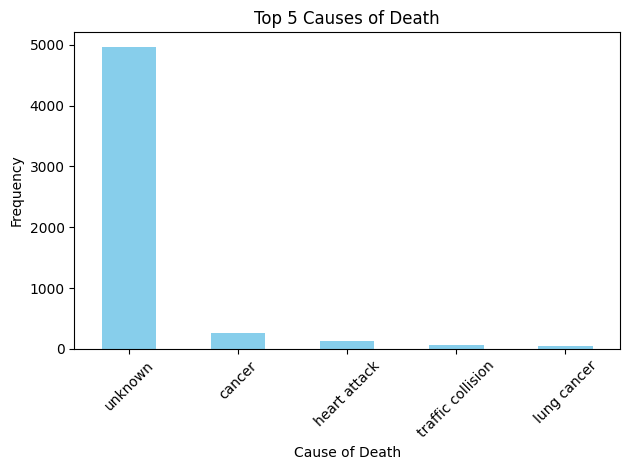

In [29]:
top_5_causes = cause_counts.head(5)
top_5_causes.plot(kind='bar', color='skyblue')
plt.title('Top 5 Causes of Death')
plt.xlabel('Cause of Death')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
## Begin Solution


















## End Solution

## Submitting Your Assignment

Please follow these steps to submit your work:

1. Ensure your name and the names of any collaborators are clearly stated in the [Your Info](#Your-Info) section at the top of the notebook.
2. Download your completed notebook as a `.ipynb` file.
3. Upload this `.ipynb` file to the designated assignment submission area in Canvas.